# Clase 05 — Tres modelos en acción: Regresión Lineal, Regresión Logística y KNN
## Naranja X — de los datos a la predicción

**Analítica de Datos · Negocios Digitales · UdeSA · Otoño 2026**

---

### La idea de esta clase
Tenemos un dataset (`solicitudes_naranjax.csv`) y un negocio con preguntas. Vamos a mostrar cómo, con el **mismo dataset**, elegimos el modelo según **qué queremos predecir**:

| Pregunta de negocio | Qué predecimos | Tipo | Modelo |
|---|---|---|---|
| ¿Cuántos años de antigüedad laboral esperamos para un solicitante de cierta edad? | un número continuo | **Regresión** | Regresión Lineal |
| ¿Este solicitante va a incumplir el crédito? | Sí / No (0 o 1) | **Clasificación** | Regresión Logística y KNN |

> La palabra "regresión" aparece en dos modelos distintos y confunde. Regla simple: **Regresión Lineal predice un número; Regresión Logística clasifica (predice una categoría).**

### El flujo, siempre igual
Para los tres modelos hacemos lo mismo: **separo train y test → entreno con train → predigo sobre test → miro métricas**. Lo que cambia es el modelo y la métrica, no el flujo.

---

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import (r2_score, mean_absolute_error,
                             accuracy_score, precision_score, confusion_matrix)

sns.set_style('whitegrid')

# Colores consistentes en todo el notebook
AZUL, ROJO = '#1565C0', '#C62828'

print('Librerias cargadas ok')

Librerias cargadas ok


---
## 2. Los datos

Cada fila es una solicitud de crédito con datos del solicitante y si terminó pagando o no.

### Diccionario de datos

| Variable | Tipo (pandas) | Tipo conceptual | Qué significa |
|---|---|---|---|
| `ingreso_mensual` | int64 | Numérica continua | Ingreso mensual declarado, en ARS |
| `score_veraz` | int64 | Numérica continua | Score crediticio del buró Veraz, 1–999 (más alto = mejor perfil) |
| `edad` | int64 | Numérica continua | Edad, en años |
| `antiguedad_laboral` | float64 | Numérica continua | Años en el empleo actual (con decimales) |
| `deuda_actual` | int64 | Numérica continua | Deuda vigente en otras entidades, en ARS |
| `relacion_laboral` | int64 | **Categórica** | Tipo de relación laboral, codificada 0 / 1 / 2 |
| `productos_naranja` | int64 | Numérica discreta (conteo) | Cantidad de productos Naranja X que ya tiene (0 a 4) |
| `incumplimiento` | int64 | **Categórica binaria — TARGET** | 1 = no pagó · 0 = pagó |

> **Ojo con los tipos:** pandas lee casi todo como número, pero *el tipo del dato no es el tipo de la variable*. `relacion_laboral` es 0/1/2 pero es **categórica** (no hay orden ni distancia real entre las categorías), e `incumplimiento` es 0/1 pero es una **etiqueta de clase**, no un número para promediar.

In [2]:
df = pd.read_csv('solicitudes_naranjax.csv')

print(f'{len(df)} solicitudes | {df.shape[1]} columnas')
df.head()

800 solicitudes | 8 columnas


,ingreso_mensual,score_veraz,edad,antiguedad_laboral,deuda_actual,relacion_laboral,productos_naranja,incumplimiento
0,968000,453,26,9.4,304000,0,0,0
1,1800000,425,58,9.5,150000,2,0,0
2,689000,466,64,10.8,606000,2,1,0
3,280000,313,22,2.0,591000,2,1,1
4,869000,434,25,5.5,551000,0,1,0


In [3]:
# Un vistazo rapido a las variables que vamos a usar
df[['edad', 'antiguedad_laboral', 'score_veraz', 'deuda_actual', 'incumplimiento']].describe().round(0)

,edad,antiguedad_laboral,score_veraz,deuda_actual,incumplimiento
count,800.0,800.0,800.0,800.0,800.0
mean,45.0,7.0,407.0,402686.0,0.0
std,13.0,4.0,121.0,325852.0,0.0
min,22.0,0.0,24.0,19000.0,0.0
25%,34.0,4.0,325.0,175500.0,0.0
50%,45.0,7.0,410.0,309000.0,0.0
75%,56.0,9.0,483.0,523500.0,1.0
max,67.0,24.0,795.0,1500000.0,1.0


---
## 3. Regresión Lineal — predecir un número

**Pregunta de negocio:** dado la **edad** de un solicitante, ¿qué **antigüedad laboral** esperamos que tenga?

Sirve, por ejemplo, para detectar declaraciones raras: si alguien de 25 años declara 20 años de antigüedad, algo no cierra. La regresión nos da la referencia "esperable".

La regresión lineal ajusta **una recta**: `antiguedad ≈ b0 + b1 * edad`. Vamos a aprender esa recta con los datos de train y evaluarla en test.

In [4]:
# La feature (X) y lo que queremos predecir (y)
X_reg = df[['edad']]
y_reg = df['antiguedad_laboral']

# Separamos: 70% para entrenar, 30% para testear
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=42)

print(f'Train: {len(Xr_train)} | Test: {len(Xr_test)}')

Train: 560 | Test: 240


In [5]:
# Entrenamos el modelo SOLO con los datos de train
lineal = LinearRegression()
lineal.fit(Xr_train, yr_train)

print(f'Recta aprendida:  antiguedad = {lineal.intercept_:.2f} + {lineal.coef_[0]:.3f} * edad')
print(f'Interpretacion: por cada anio de edad, ~{lineal.coef_[0]:.2f} anios mas de antiguedad esperada')

Recta aprendida:  antiguedad = -1.47 + 0.187 * edad
Interpretacion: por cada anio de edad, ~0.19 anios mas de antiguedad esperada


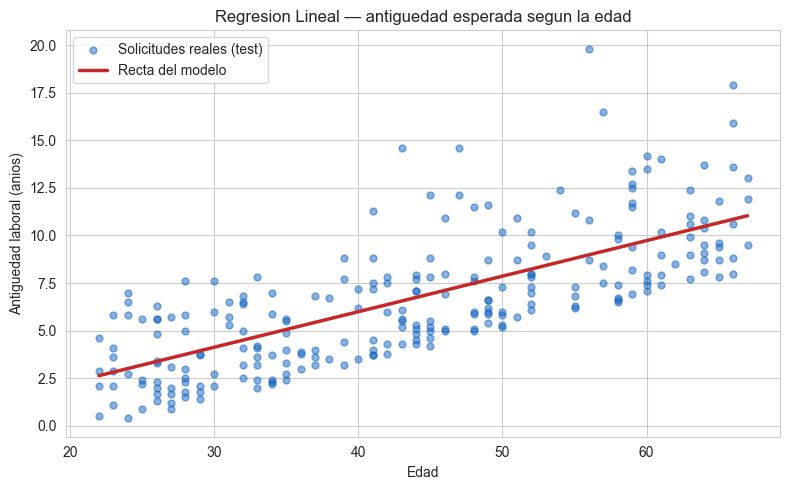

In [6]:
# Visualizamos: puntos reales de test + la recta que aprendio el modelo
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(Xr_test['edad'], yr_test, color=AZUL, alpha=0.5, s=25, label='Solicitudes reales (test)')

edades = np.linspace(df['edad'].min(), df['edad'].max(), 100).reshape(-1, 1)
edades_df = pd.DataFrame(edades, columns=['edad'])
ax.plot(edades_df['edad'], lineal.predict(edades_df), color=ROJO, lw=2.5, label='Recta del modelo')

ax.set_xlabel('Edad')
ax.set_ylabel('Antiguedad laboral (anios)')
ax.set_title('Regresion Lineal — antiguedad esperada segun la edad')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Metricas: predecimos sobre test (datos que el modelo NUNCA vio) y comparamos con la realidad
yr_pred = lineal.predict(Xr_test)

r2  = r2_score(yr_test, yr_pred)
mae = mean_absolute_error(yr_test, yr_pred)

print(f'R2:  {r2:.2f}  -> el modelo explica el {r2:.0%} de la variacion de la antiguedad')
print(f'MAE: {mae:.2f} anios  -> en promedio le erra por ~{mae:.1f} anios')

R2:  0.54  -> el modelo explica el 54% de la variacion de la antiguedad
MAE: 1.91 anios  -> en promedio le erra por ~1.9 anios


In [8]:
# Usar el modelo: un solicitante nuevo de 40 anios
nuevo = pd.DataFrame({'edad': [40]})
pred = lineal.predict(nuevo)[0]
print(f'Solicitante de 40 anios -> antiguedad esperada: {pred:.1f} anios')

Solicitante de 40 anios -> antiguedad esperada: 6.0 anios


**Para leer con los alumnos:** R2 de ~0.54 no es perfecto, y está bien: la edad explica *parte* de la antigüedad, no toda (alguien puede haber empezado a trabajar tarde). El MAE nos da el error en la unidad del negocio —años— que es más fácil de comunicar que el R2.

### Regresión Lineal Múltiple — ¿ayuda sumar más variables?

Hasta acá usamos **una sola** variable (`edad`). La regresión lineal múltiple usa **varias a la vez**: en vez de una recta, ajusta un plano con un coeficiente por variable:

`antiguedad ≈ b0 + b1*edad + b2*score + b3*ingreso + b4*productos`

La intuición del alumno suele ser "más variables = mejor modelo". Probémoslo y veamos si es cierto acá.

In [9]:
# Ahora X tiene VARIAS columnas. Mismo target y mismo split (random_state=42) para comparar de igual a igual
features_mult = ['edad', 'score_veraz', 'ingreso_mensual', 'productos_naranja']
X_mult = df[features_mult]

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_mult, y_reg, test_size=0.30, random_state=42)

lineal_mult = LinearRegression()
lineal_mult.fit(Xm_train, ym_train)

# Un coeficiente por variable: cuanto suma (o resta) cada una a la antiguedad esperada
coefs = pd.Series(lineal_mult.coef_, index=features_mult).round(4)
print('Coeficientes:')
print(coefs.to_string())

Coeficientes:
edad                 0.1844
score_veraz          0.0023
ingreso_mensual     -0.0000
productos_naranja    0.2232


In [10]:
# Metricas del modelo multiple sobre el MISMO test
ym_pred = lineal_mult.predict(Xm_test)
r2_mult  = r2_score(ym_test, ym_pred)
mae_mult = mean_absolute_error(ym_test, ym_pred)

# Comparamos contra el simple (r2 y mae calculados antes)
comp_reg = pd.DataFrame({
    'R2':  [r2,  r2_mult],
    'MAE (anios)': [mae, mae_mult]
}, index=['Simple (solo edad)', 'Multiple (4 variables)']).round(3)

comp_reg

,R2,MAE (anios)
Simple (solo edad),0.541,1.908
Multiple (4 variables),0.540,1.892


**El resultado sorprende (y es el punto de la sección):** pasar de 1 a 4 variables **casi no mejora** el R2 ni el MAE. ¿Por qué? Porque `edad` ya capturaba casi toda la señal, y las otras (score, ingreso, productos) tienen muy poca relación con la antigüedad —se ve en sus coeficientes chiquitos—.

Moraleja: **sumar variables no garantiza un mejor modelo.** Solo ayudan las que aportan información nueva y relevante. Meter variables porque sí agrega ruido y complejidad sin ganancia (y a veces empeora en datos nuevos).

---
## 4. Cambiamos de pregunta: ahora clasificamos

**Pregunta de negocio:** ¿este solicitante va a **incumplir** el crédito (1) o lo va a **pagar** (0)?

Ya no predecimos un número sino una **categoría**. Para eso usamos dos modelos: **Regresión Logística** y **KNN**.

Para poder **ver la frontera de decisión** en un gráfico usamos dos variables: `score_veraz` y `deuda_actual` (las más relacionadas con el incumplimiento).

In [11]:
# Features para clasificar y el target
X_clf = df[['score_veraz', 'deuda_actual']]
y_clf = df['incumplimiento']

# Mismo flujo: separamos train y test. stratify mantiene la misma proporcion de incumplidores en ambos
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.30, random_state=42, stratify=y_clf)

print(f'Train: {len(Xc_train)} | Test: {len(Xc_test)}')
print(f'Incumplimiento en el total: {y_clf.mean():.0%}')

Train: 560 | Test: 240
Incumplimiento en el total: 42%


### Un paso obligatorio para KNN: escalar las variables

`score_veraz` va de 1 a 999; `deuda_actual` llega a $1.500.000. KNN mide **distancias** entre solicitudes, así que sin ajustar la escala una diferencia de $100.000 en deuda pesaría muchísimo más que 100 puntos de score: la deuda aplastaría al score y KNN casi lo ignoraría.

La solución es **estandarizar**: llevar cada variable a media 0 y desvío 1, para que las dos midan en la misma "regla". Lo hacemos con `StandardScaler` en dos pasos:

- **`fit_transform` sobre train** — el scaler *aprende* la media y el desvío con los datos de train, y los transforma.
- **`transform` sobre test** — aplicamos esa **misma** escala al test (nunca volvemos a aprenderla con test: sería hacer trampa mirando datos que el modelo no debería conocer).

La Regresión Logística no lo necesita para funcionar, pero vamos a usar las mismas variables escaladas en ambos modelos para poder compararlos de igual a igual.

In [12]:
# Escalado explicito: fit SOLO con train, transform sobre train y test
scaler = StandardScaler()

X_train_sc = pd.DataFrame(scaler.fit_transform(Xc_train), columns=Xc_train.columns, index=Xc_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(Xc_test),      columns=Xc_test.columns,  index=Xc_test.index)

X_train_sc.head(3)

,score_veraz,deuda_actual
19,0.604906,-0.847178
528,0.207344,0.186657
136,-0.596061,-1.123277


In [13]:
# Veamos QUE hizo el escalado: antes las escalas eran muy distintas; despues, media ~0 y desvio ~1 en ambas
antes    = Xc_train.agg(['mean', 'std']).round(0)
despues  = X_train_sc.agg(['mean', 'std']).round(2)

print('ANTES de escalar (unidades originales):')
print(antes.to_string())
print()
print('DESPUES de escalar (media ~0, desvio ~1):')
print(despues.to_string())

ANTES de escalar (unidades originales):
      score_veraz  deuda_actual
mean        410.0      402155.0
std         121.0      326262.0

DESPUES de escalar (media ~0, desvio ~1):
      score_veraz  deuda_actual
mean          0.0          -0.0
std           1.0           1.0


---
## 5. Regresión Logística — clasificar con una frontera recta

Aprende una **probabilidad de incumplimiento** entre 0 y 1 para cada solicitud, y con un umbral (por defecto 0.5) decide. Su frontera de decisión es **siempre una recta**. La entrenamos con las variables ya escaladas.

In [14]:
# Entrenamos con train (escalado) y predecimos sobre test (escalado)
logistica = LogisticRegression(max_iter=1000, random_state=42)
logistica.fit(X_train_sc, yc_train)

yc_pred_log = logistica.predict(X_test_sc)

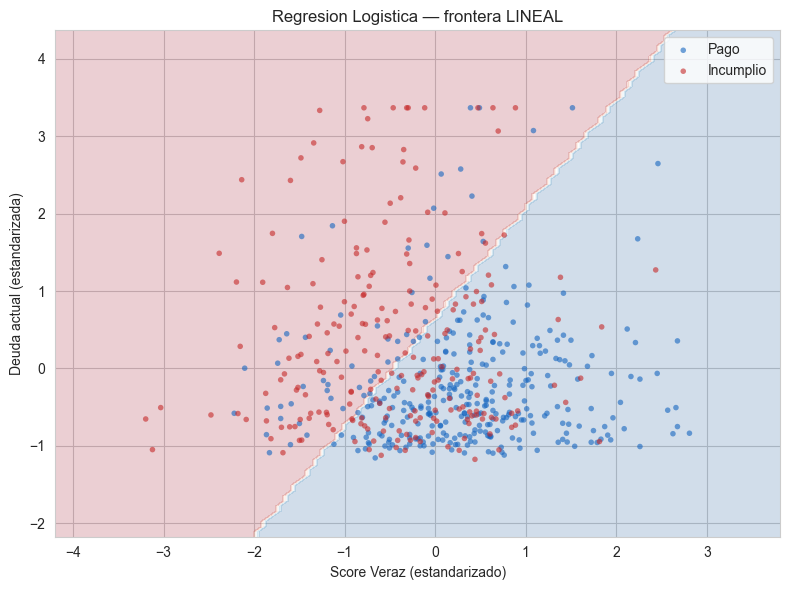

In [15]:
# Frontera de decision. Ojo: los ejes estan en unidades ESTANDARIZADAS (media 0, desvio 1),
# que es el espacio en el que los modelos ven los datos despues de escalar.
fig, ax = plt.subplots(figsize=(8, 6))

DecisionBoundaryDisplay.from_estimator(
    logistica, X_train_sc, ax=ax, response_method='predict',
    cmap='RdBu_r', alpha=0.20)

for clase, color, etiqueta in [(0, AZUL, 'Pago'), (1, ROJO, 'Incumplio')]:
    mask = yc_train == clase
    ax.scatter(X_train_sc[mask]['score_veraz'], X_train_sc[mask]['deuda_actual'],
               c=color, s=16, alpha=0.6, edgecolors='none', label=etiqueta)

ax.set_xlabel('Score Veraz (estandarizado)')
ax.set_ylabel('Deuda actual (estandarizada)')
ax.set_title('Regresion Logistica — frontera LINEAL')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Metricas basicas sobre test
acc_log  = accuracy_score(yc_test, yc_pred_log)
prec_log = precision_score(yc_test, yc_pred_log, zero_division=0)

print(f'Accuracy:  {acc_log:.1%}  -> % de solicitudes clasificadas bien')
print(f'Precision: {prec_log:.1%}  -> de las que marca como incumplidoras, cuantas realmente lo eran')

Accuracy:  67.5%  -> % de solicitudes clasificadas bien
Precision: 62.5%  -> de las que marca como incumplidoras, cuantas realmente lo eran


---
## 6. KNN — clasificar mirando a los vecinos

KNN no aprende una fórmula: para clasificar una solicitud nueva, mira las **K solicitudes más parecidas** del historial y vota por mayoría. Con K=7 mira los 7 vecinos más cercanos.

Su frontera es **flexible** (se adapta a la forma de los datos), a diferencia de la recta de la logística.

In [17]:
# KNN se entrena con las MISMAS variables escaladas (por eso escalamos antes)
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_sc, yc_train)

yc_pred_knn = knn.predict(X_test_sc)

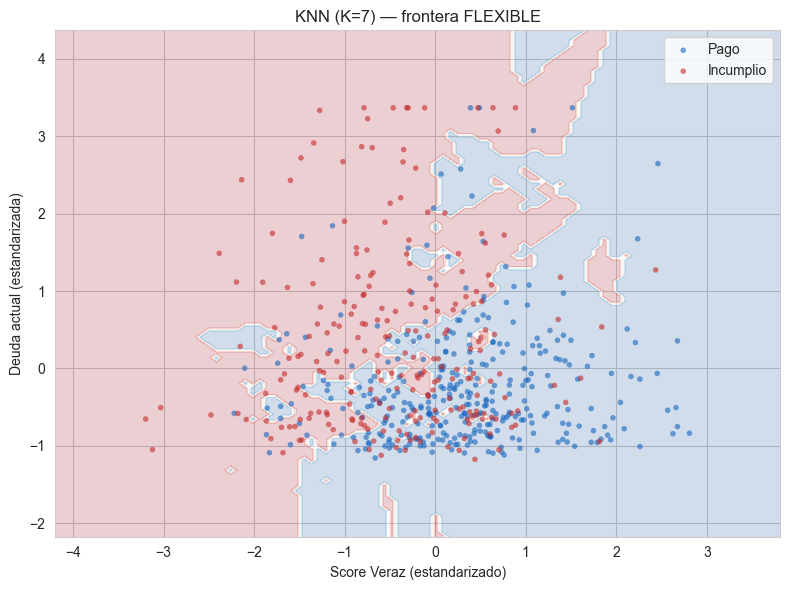

In [18]:
# Misma visualizacion (ejes estandarizados), ahora con la frontera flexible de KNN
fig, ax = plt.subplots(figsize=(8, 6))

DecisionBoundaryDisplay.from_estimator(
    knn, X_train_sc, ax=ax, response_method='predict',
    cmap='RdBu_r', alpha=0.20)

for clase, color, etiqueta in [(0, AZUL, 'Pago'), (1, ROJO, 'Incumplio')]:
    mask = yc_train == clase
    ax.scatter(X_train_sc[mask]['score_veraz'], X_train_sc[mask]['deuda_actual'],
               c=color, s=16, alpha=0.6, edgecolors='none', label=etiqueta)

ax.set_xlabel('Score Veraz (estandarizado)')
ax.set_ylabel('Deuda actual (estandarizada)')
ax.set_title('KNN (K=7) — frontera FLEXIBLE')
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
# Mismas metricas para poder comparar de igual a igual
acc_knn  = accuracy_score(yc_test, yc_pred_knn)
prec_knn = precision_score(yc_test, yc_pred_knn, zero_division=0)

print(f'Accuracy:  {acc_knn:.1%}')
print(f'Precision: {prec_knn:.1%}')

Accuracy:  65.4%
Precision: 59.6%


---
## 7. Comparación y cierre

Los dos clasificadores lado a lado, con la misma métrica y la matriz de confusión —que muestra *dónde* se equivoca cada uno.

In [20]:
# Tabla comparativa
comparacion = pd.DataFrame({
    'Regresion Logistica': [acc_log, prec_log],
    'KNN (K=7)':           [acc_knn, prec_knn]
}, index=['Accuracy', 'Precision']).round(3)

comparacion

,Regresion Logistica,KNN (K=7)
Accuracy,0.675,0.654
Precision,0.625,0.596


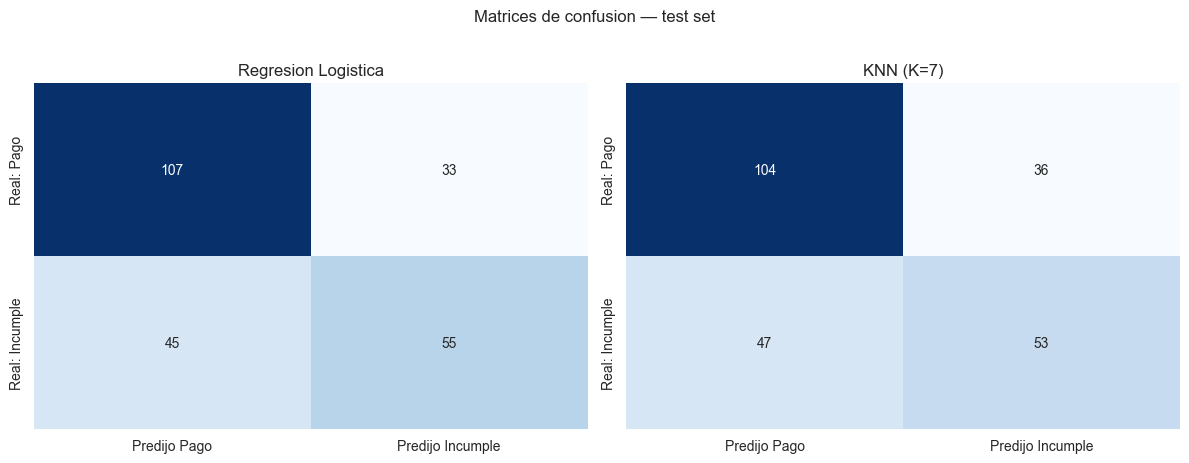

In [21]:
# Matrices de confusion: filas = realidad, columnas = lo que predijo el modelo
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, y_pred, titulo in zip(axes,
    [yc_pred_log, yc_pred_knn], ['Regresion Logistica', 'KNN (K=7)']):
    cm = confusion_matrix(yc_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Predijo Pago', 'Predijo Incumple'],
                yticklabels=['Real: Pago', 'Real: Incumple'])
    ax.set_title(titulo)

plt.suptitle('Matrices de confusion — test set', y=1.02)
plt.tight_layout()
plt.show()

### Qué nos llevamos

- **Un solo dataset, dos tipos de pregunta.** Si predecimos un **número** → Regresión Lineal. Si predecimos una **categoría** → Regresión Logística o KNN.
- **El flujo es siempre el mismo:** train / test → entreno → predigo → mido. Cambia el modelo y la métrica, no la receta.
- **Regresión** se mide con R2 y MAE (error en la unidad del negocio). **Clasificación** con accuracy, precision y la matriz de confusión.
- **Logística vs KNN:** performance parecida, pero la logística da una frontera recta e **interpretable** ("tal score + tal deuda = tanta probabilidad"), mientras que KNN es más flexible pero explica menos *por qué* decidió.

En la próxima clase profundizamos en las **métricas** de clasificación: cuándo accuracy engaña y por qué el umbral es una decisión de negocio.